In [ ]:
!pip install pennylane

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------
# SAFE MATPLOTLIB CONFIG
# -------------------------------------------------
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.size"] = 11
mpl.rcParams["figure.dpi"] = 300

FIGSIZE = (6.2, 4.2)

# -------------------------------------------------
# Noise scales
# -------------------------------------------------
noise_scales = np.array([0.02, 0.15, 0.25])
YMIN, YMAX = 0.80, 0.92

# -------------------------------------------------
# UPDATED VALUES (AUTHORITATIVE)
# -------------------------------------------------
acc_no_zne = {
    "Pauli Noise": np.array([0.8900, 0.8565, 0.8135]),
    "Phase-Damping Noise": np.array([0.8856, 0.8723, 0.8611]),
    "Depolarizing Noise": np.array([0.8894, 0.8527, 0.8116]),
}

acc_zne = {
    "Pauli Noise": np.array([0.8679, 0.8603, 0.8515]),
    "Phase-Damping Noise": np.array([0.8704, 0.8647, 0.8554]),
    "Depolarizing Noise": np.array([0.8673, 0.8597, 0.8515]),
}

# -------------------------------------------------
# PLOTTING FUNCTION (4 LEGENDS, UPDATED VALUES)
# -------------------------------------------------
def plot_zne(noise_type, acc_no, acc_zne_vals):

    # Polynomial ZNE fit (visual trend)
    coeffs = np.polyfit(noise_scales, acc_no, deg=2)
    poly = np.poly1d(coeffs)

    x_fit = np.linspace(0.0, 0.27, 300)
    y_fit = poly(x_fit)
    zne_extrapolated = poly(0.0)

    fig, ax = plt.subplots(figsize=FIGSIZE)

    # ---- Measured (No ZNE) ----
    ax.scatter(
        noise_scales, acc_no,
        s=110, color="#ff6f61",
        edgecolor="black", zorder=3
    )

    for x, y in zip(noise_scales, acc_no):
        ax.annotate(
            f"{y:.4f}", (x, y),
            xytext=(0, -26),
            textcoords="offset points",
            ha="center", va="top",
            fontsize=10, fontweight="bold"
        )

    # ---- Polynomial ZNE fit ----
    ax.plot(
        x_fit, y_fit,
        "--", linewidth=2, color="#1f77b4"
    )

    # ---- Extrapolated (Noise → 0) ----
    ax.scatter(
        0.0, zne_extrapolated,
        s=160, marker="*",
        color="#2ca02c",
        edgecolor="black", zorder=5
    )

    ax.annotate(
        f"{zne_extrapolated:.4f}", (0.0, zne_extrapolated),
        xytext=(0, 30),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold",
        color="green"
    )

    # ---- Measured (ZNE) ----
    ax.scatter(
        noise_scales, acc_zne_vals,
        s=90, marker="D",
        color="#1f77b4",
        edgecolor="black", zorder=4
    )

    for x, y in zip(noise_scales, acc_zne_vals):
        ax.annotate(
            f"{y:.4f}", (x, y),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold",
            color="#1f77b4"
        )

    # ---- Axis formatting ----
    ax.set_xlim(-0.01, 0.27)
    ax.set_ylim(YMIN, YMAX)
    ax.set_xlabel("Noise Scale Factor")
    ax.set_ylabel("Classification Accuracy")
    ax.set_title(f"ZNE Process – {noise_type}")
    ax.grid(True, linestyle="--", alpha=0.5)

    # ---- Legend (4 entries, explicit) ----
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label='Measured (No ZNE)',
               markerfacecolor='#ff6f61',
               markeredgecolor='black', markersize=9),

        Line2D([0], [0], linestyle='--', color='#1f77b4',
               label='Polynomial ZNE Fit'),

        Line2D([0], [0], marker='*', color='w',
               label='Extrapolated (Noise → 0)',
               markerfacecolor='#2ca02c',
               markeredgecolor='black', markersize=12),

        Line2D([0], [0], marker='D', color='w',
               label='Measured (ZNE)',
               markerfacecolor='#1f77b4',
               markeredgecolor='black', markersize=7),
    ]

    ax.legend(handles=legend_elements, loc="upper right", frameon=True)

    plt.tight_layout()
    plt.savefig(
        noise_type.lower().replace(" ", "_") + "_zne_updated_4legend.png",
        dpi=300, bbox_inches="tight"
    )
    plt.close()

# -------------------------------------------------
# GENERATE ALL FIGURES
# -------------------------------------------------
for noise in acc_no_zne:
    plot_zne(noise, acc_no_zne[noise], acc_zne[noise])

In [ ]:
from IPython.display import clear_output
clear_output(wait=True) # Set wait=True to wait until new output is ready

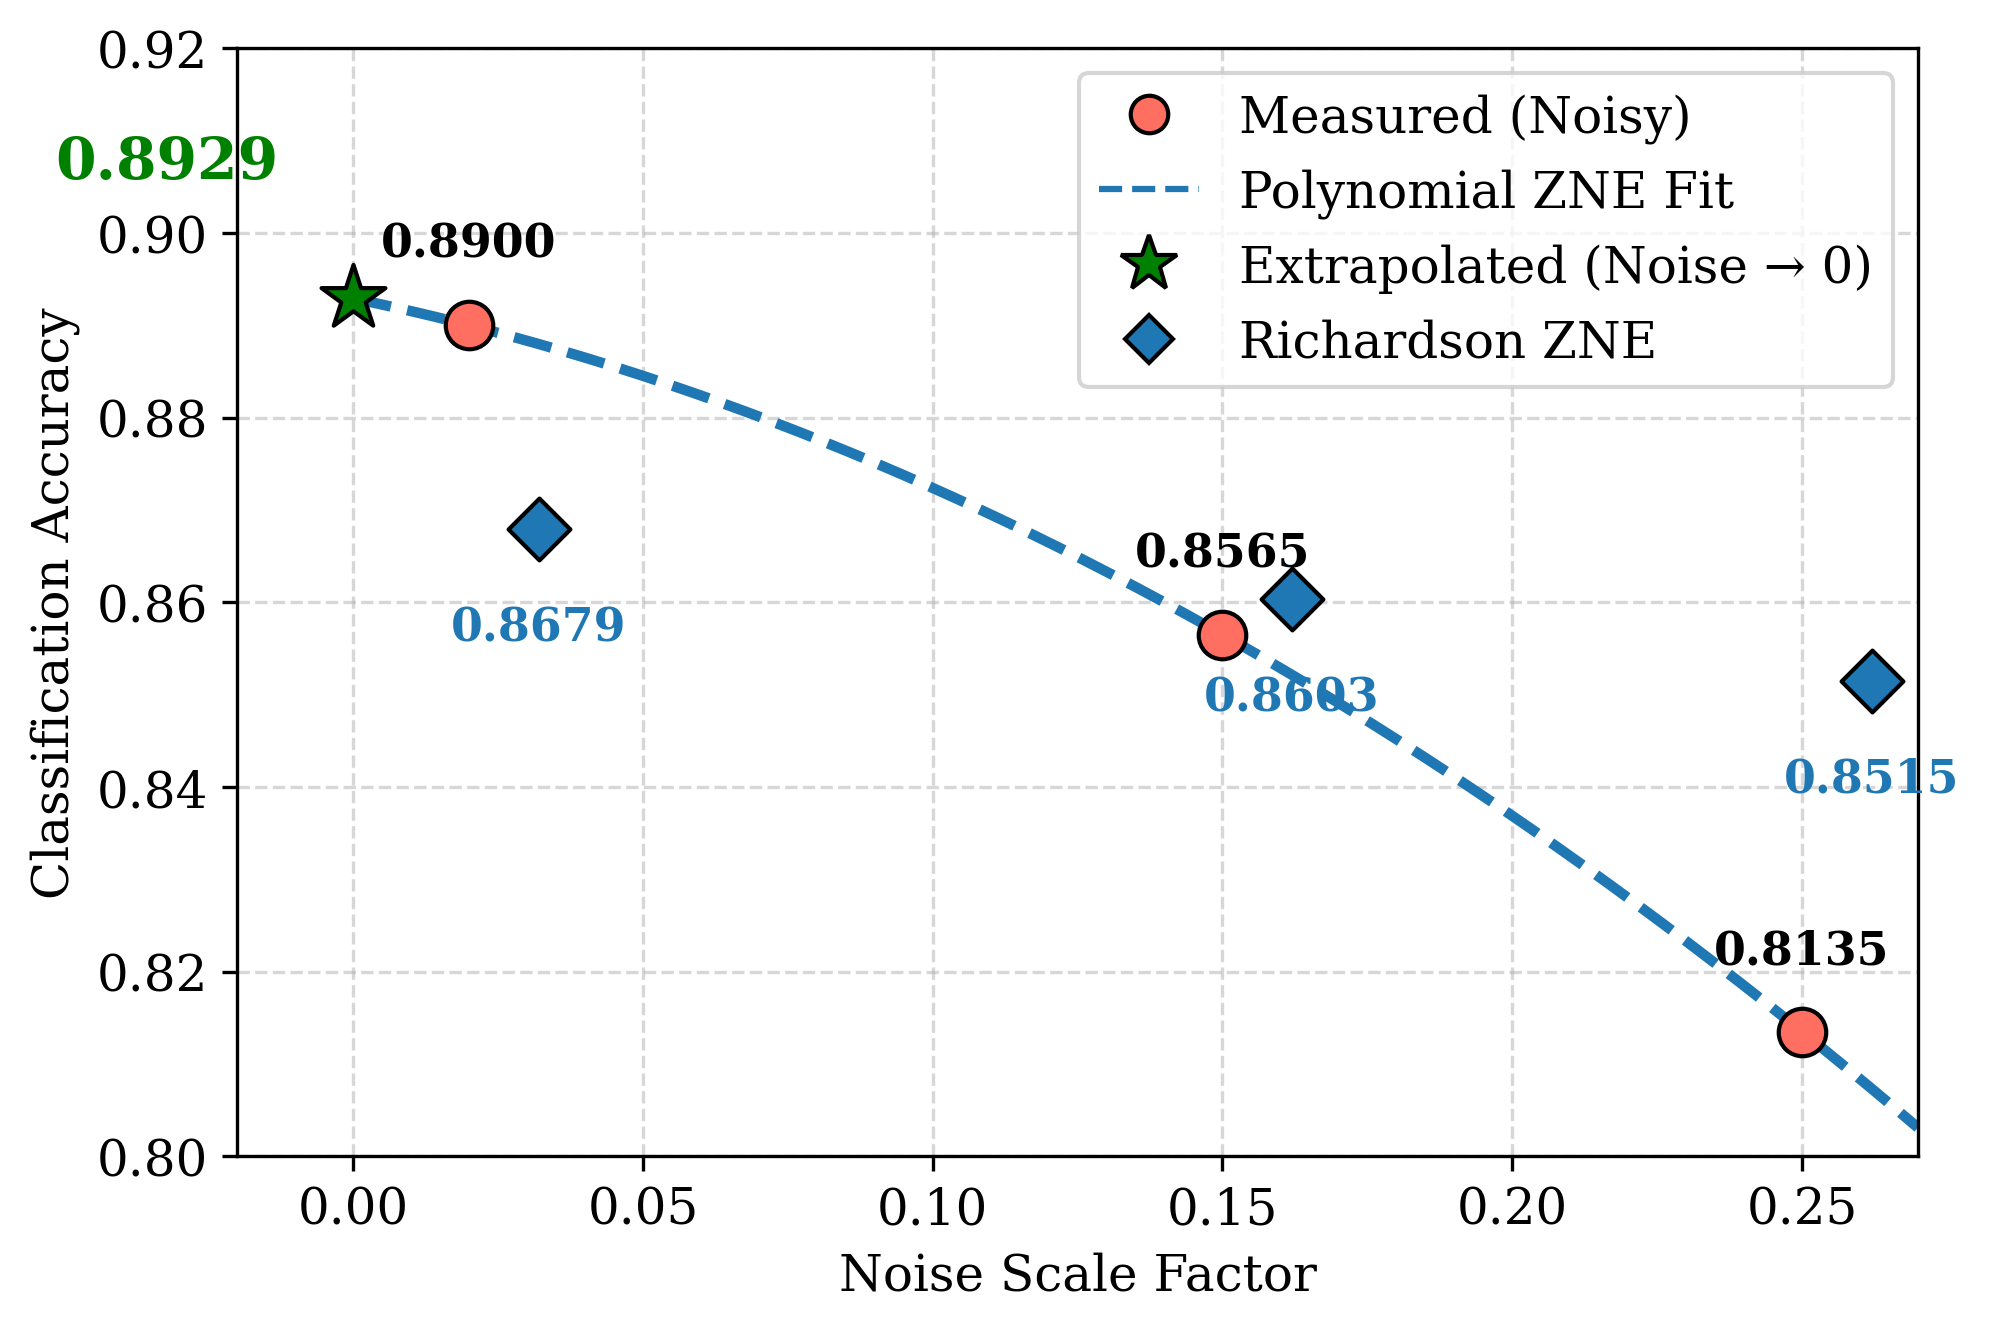

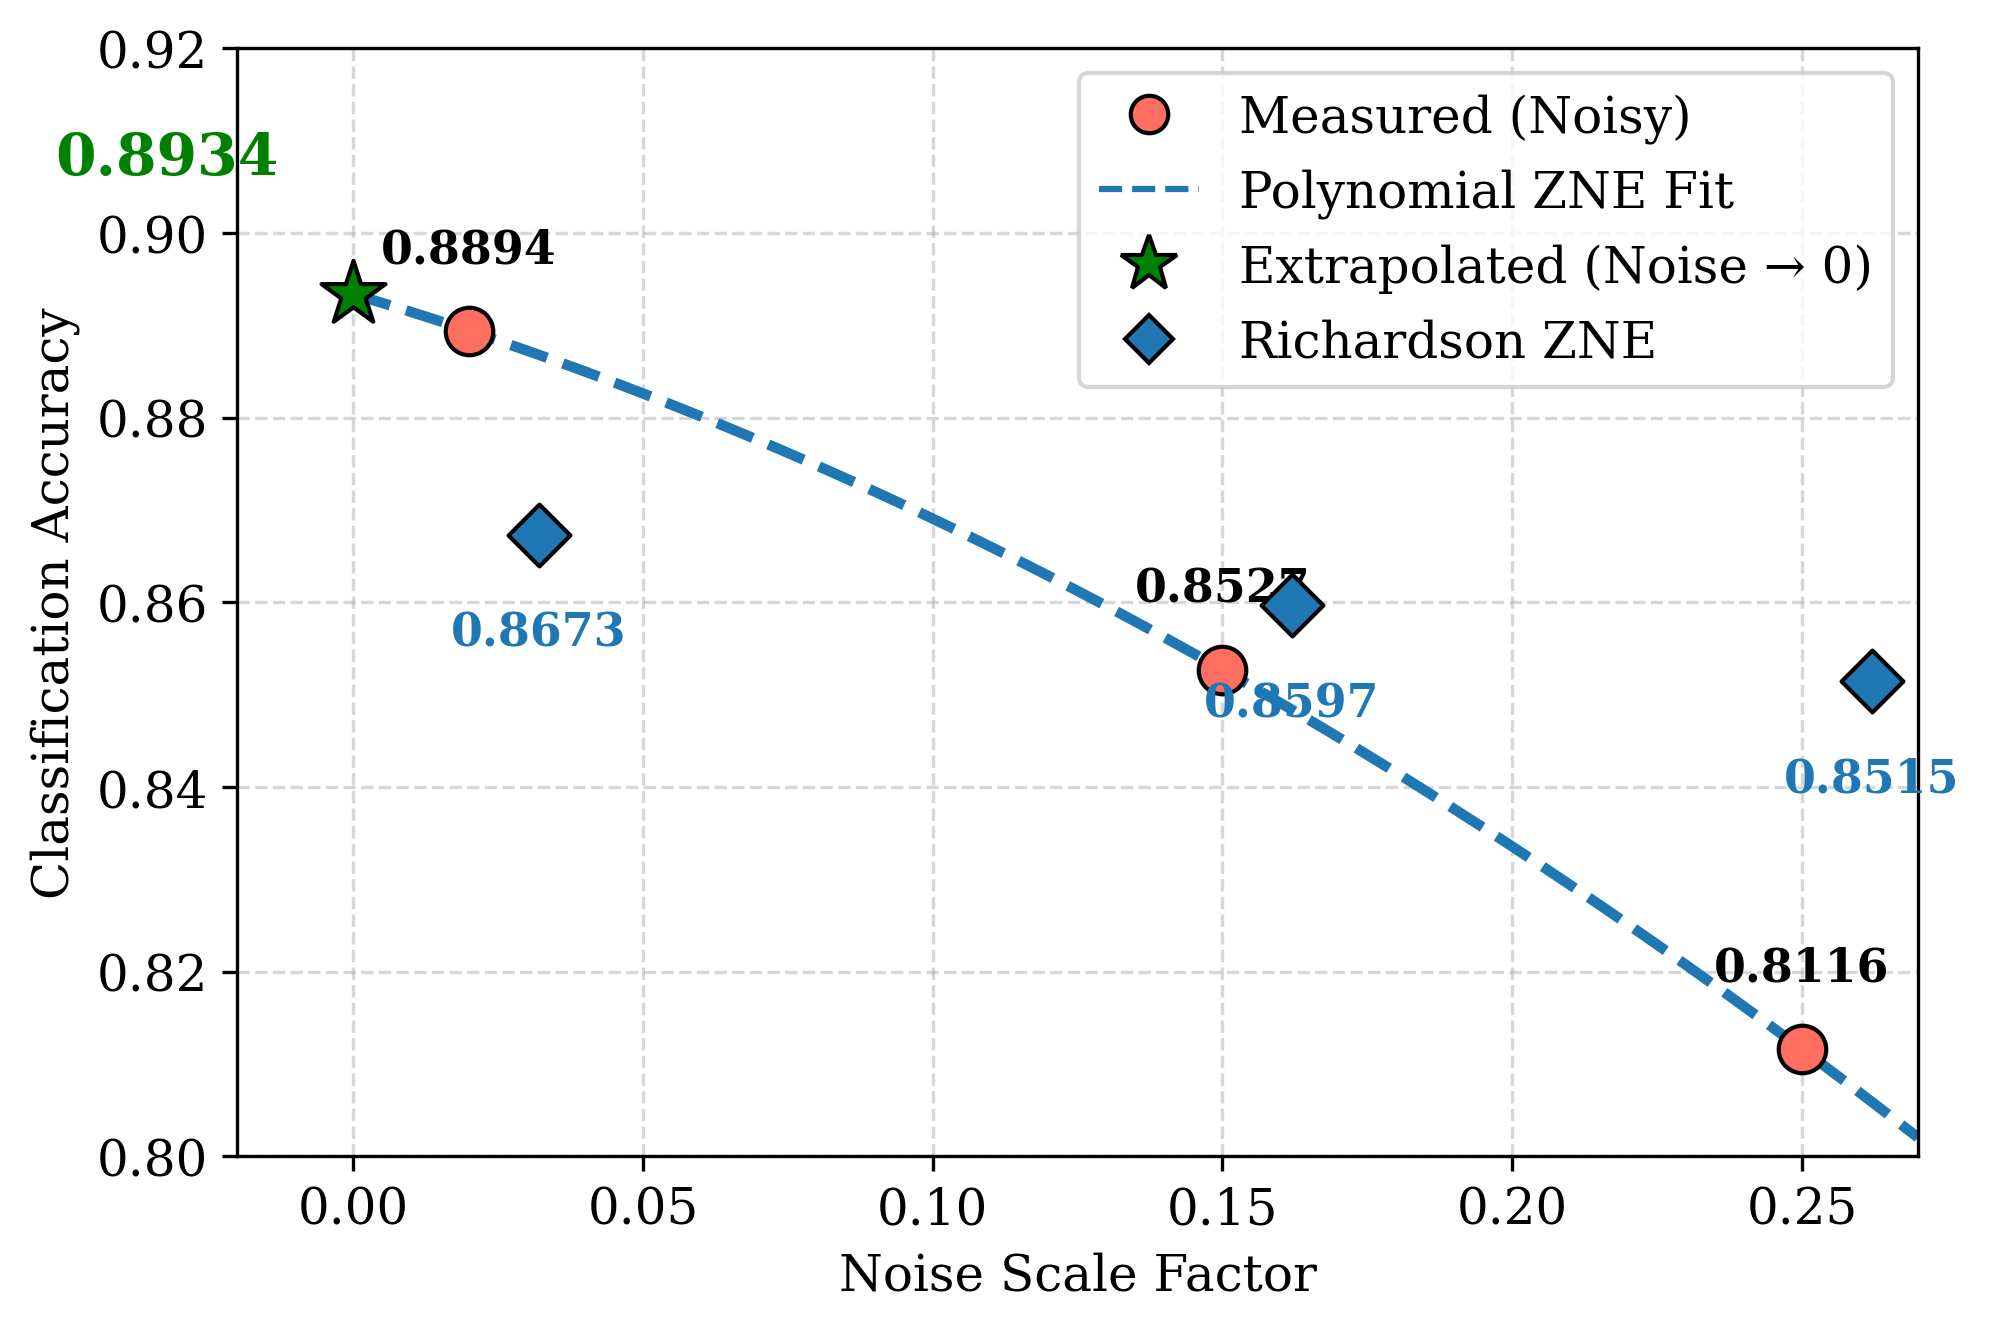

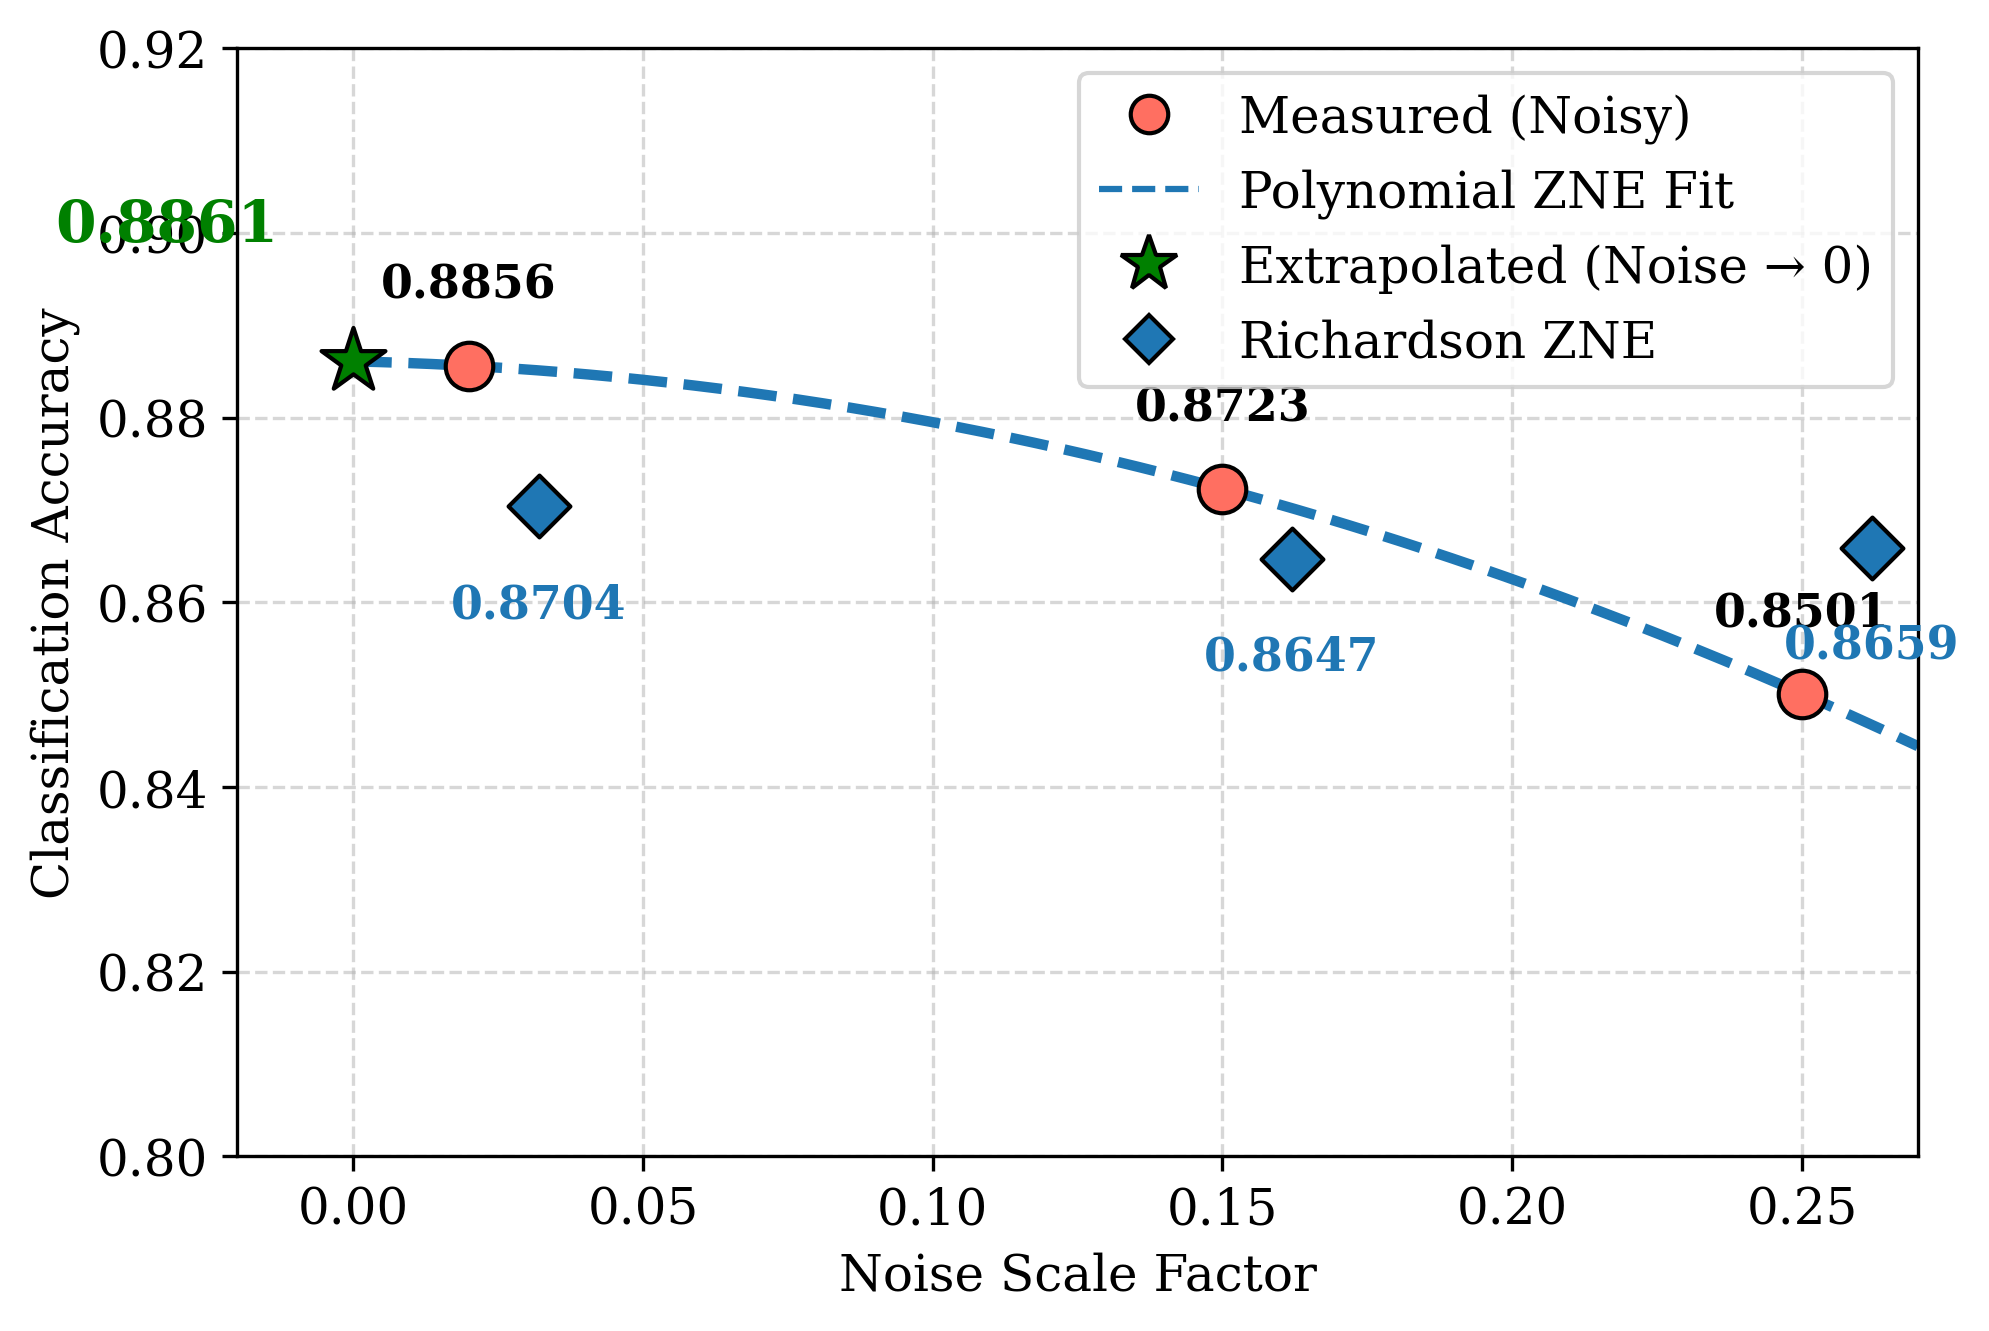

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------------------------------
# Matplotlib configuration
# -------------------------------------------------
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.size"] = 12
mpl.rcParams["figure.dpi"] = 300

FIGSIZE = (6.8, 4.6)

# -------------------------------------------------
# Noise scales
# -------------------------------------------------
noise_scales = np.array([0.02, 0.15, 0.25])

# -------------------------------------------------
# FINAL DATA
# -------------------------------------------------
acc_no_zne = {
    "Pauli Noise": np.array([0.8900, 0.8565, 0.8135]),
    "Depolarizing Noise": np.array([0.8894, 0.8527, 0.8116]),
    "Phase-Damping Noise": np.array([0.8856, 0.8723, 0.8501]),
}

acc_zne = {
    "Pauli Noise": np.array([0.8679, 0.8603, 0.8515]),
    "Depolarizing Noise": np.array([0.8673, 0.8597, 0.8515]),
    "Phase-Damping Noise": np.array([0.8704, 0.8647, 0.8659]),
}

# -------------------------------------------------
# Plotting function
# -------------------------------------------------
def plot_zne(noise_type, acc_no, acc_zne_vals):

    coeffs = np.polyfit(noise_scales, acc_no, deg=2)
    poly = np.poly1d(coeffs)

    x_fit = np.linspace(0.0, 0.27, 300)
    y_fit = poly(x_fit)
    zne_extrapolated = poly(0.0)

    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Polynomial ZNE fit
    ax.plot(x_fit, y_fit, "--", linewidth=2.5, color="#1f77b4")

    # ---- Measured (Noisy) ----
    ax.scatter(
        noise_scales, acc_no,
        s=130, color="#ff6f61",
        edgecolor="black", zorder=3
    )

    # ---- Richardson ZNE (x-jittered) ----
    x_jitter = 0.012
    ax.scatter(
        noise_scales + x_jitter, acc_zne_vals,
        s=110, marker="D",
        color="#1f77b4",
        edgecolor="black", zorder=4
    )

    # ---- Extrapolated ----
    ax.scatter(
        0.0, zne_extrapolated,
        s=260, marker="*",
        color="green",
        edgecolor="black", zorder=5
    )

    # -------------------------------------------------
    # Labels
    # -------------------------------------------------

    # Measured (Noisy) → ABOVE markers
    for x, y in zip(noise_scales, acc_no):
        ax.annotate(
            f"{y:.4f}", (x, y),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold"
        )

    # Richardson ZNE → BELOW diamonds
    for x, y in zip(noise_scales + x_jitter, acc_zne_vals):
        ax.annotate(
            f"{y:.4f}", (x, y),
            xytext=(0, -18),
            textcoords="offset points",
            ha="center", va="top",
            fontsize=11, fontweight="bold",
            color="#1f77b4"
        )

    # Extrapolated → ABOVE star
    ax.annotate(
        f"{zne_extrapolated:.4f}",
        (0.0, zne_extrapolated),
        xytext=(-18, 26),
        textcoords="offset points",
        ha="right", va="bottom",
        fontsize=14, fontweight="bold",
        color="green"
    )

    # -------------------------------------------------
    # Axes
    # -------------------------------------------------
    ax.set_xlim(-0.02, 0.27)
    ax.set_ylim(0.80, 0.92)
    ax.set_xlabel("Noise Scale Factor")
    ax.set_ylabel("Classification Accuracy")
    ax.grid(True, linestyle="--", alpha=0.5)

    # -------------------------------------------------
    # Legend
    # -------------------------------------------------
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label='Measured (Noisy)',
               markerfacecolor='#ff6f61', markeredgecolor='black', markersize=9),
        Line2D([0], [0], linestyle='--', color='#1f77b4',
               label='Polynomial ZNE Fit'),
        Line2D([0], [0], marker='*', color='w',
               label='Extrapolated (Noise → 0)',
               markerfacecolor='green', markeredgecolor='black', markersize=14),
        Line2D([0], [0], marker='D', color='w',
               label='Richardson ZNE',
               markerfacecolor='#1f77b4', markeredgecolor='black', markersize=8),
    ]

    ax.legend(handles=legend_elements, loc="upper right", frameon=True)

    plt.tight_layout()
    plt.savefig(
        noise_type.lower().replace("-", "_").replace(" ", "_") + "_zne_final.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

# -------------------------------------------------
# Generate all figures
# -------------------------------------------------
for noise in acc_no_zne:
    plot_zne(noise, acc_no_zne[noise], acc_zne[noise])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

noise_strengths = [0.02, 0.15, 0.25]
metrics = ["accuracy", "precision", "recall", "f1", "specificity"]
noise_types = df["noise_type"].unique()

# Radar setup
N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

for p_sel in noise_strengths:
    sub_p = df[df["noise_strength"] == p_sel]

    for nt in noise_types:
        row = sub_p[sub_p["noise_type"] == nt].iloc[0]

        no_zne = [
            row["accuracy_no_zne"],
            row["precision_no_zne"],
            row["recall_no_zne"],
            row["f1_no_zne"],
            row["specificity_no_zne"],
        ]
        zne = [
            row["accuracy_zne"],
            row["precision_zne"],
            row["recall_zne"],
            row["f1_zne"],
            row["specificity_zne"],
        ]

        # close values
        no_zne += no_zne[:1]
        zne += zne[:1]

        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

        ax.plot(angles, no_zne, linewidth=2, label="No ZNE")
        ax.fill(angles, no_zne, alpha=0.2)

        ax.plot(angles, zne, linewidth=2, label="With ZNE")
        ax.fill(angles, zne, alpha=0.2)

        ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
        ax.set_ylim(0, 1.0)

        ax.set_title(f"{nt.capitalize()} Noise | p = {p_sel}", pad=20)
        ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

        plt.tight_layout()
        plt.savefig(f"radar_{nt}_p{p_sel}.png", dpi=300)
        plt.show()
        plt.close()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/qtl-results-post-meeting/qtl_sweep_results (2).csv')

noise_display_map = {
    'pauli': 'Pauli',
    'phase': 'Phase-damping',
    'depolarizing': 'Depolarizing'
}
df['noise_type_display'] = df['noise_type'].map(noise_display_map)

df['accuracy_drop'] = 1.0 - df['accuracy_no_zne']
df['relative_recovery'] = df['zne_gain'] / df['accuracy_drop']

colors = {'Pauli': 'tab:blue', 'Phase-damping': 'tab:orange', 'Depolarizing': 'tab:green'}
markers = {'Pauli': 'o', 'Phase-damping': 's', 'Depolarizing': '^'}
noise_strengths = sorted(df['noise_strength'].unique())

# 1. Accuracy vs. Noise Strength (acc.png)
plt.clf()
for nt in df['noise_type_display'].unique():
    subset = df[df['noise_type_display'] == nt].sort_values('noise_strength')
    plt.plot(subset['noise_strength'], subset['accuracy_zne'], label=f'{nt} (ZNE)', 
             color=colors[nt], marker=markers[nt], linestyle='-')
    plt.plot(subset['noise_strength'], subset['accuracy_no_zne'], label=f'{nt} (No ZNE)', 
             color=colors[nt], marker=markers[nt], linestyle='--', alpha=0.5)

plt.xlabel('Noise Strength ($p$)')
plt.ylabel('Accuracy')
plt.xticks(noise_strengths)
plt.legend(loc='best', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('acc.png', dpi=300)


In [ ]:
# 2. Accuracy Degradation (acc_deg.png)
plt.clf()
for nt in df['noise_type_display'].unique():
    subset = df[df['noise_type_display'] == nt].sort_values('noise_strength')
    plt.plot(subset['noise_strength'], subset['accuracy_drop'], label=nt, 
             color=colors[nt], marker=markers[nt], linestyle='-')

plt.xlabel('Noise Strength ($p$)')
plt.ylabel('Accuracy Drop ($1 - \text{Acc}_{\text{No ZNE}}$)')
plt.xticks(noise_strengths)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('acc_deg.png' , dpi=300)



In [ ]:
# 3. Relative ZNE Recovery (rel_rec.png)
plt.clf()
for nt in df['noise_type_display'].unique():
    subset = df[df['noise_type_display'] == nt].sort_values('noise_strength')
    plt.plot(subset['noise_strength'], subset['relative_recovery'], label=nt, 
             color=colors[nt], marker=markers[nt], linestyle='-')

plt.xlabel('Noise Strength ($p$)')
plt.ylabel('Relative Recovery Ratio')
plt.xticks(noise_strengths)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('rel_rec.png', dpi=300)



In [ ]:
# 4. Absolute ZNE Accuracy Gain (rec_gain.png)
plt.clf()
for nt in df['noise_type_display'].unique():
    subset = df[df['noise_type_display'] == nt].sort_values('noise_strength')
    plt.plot(subset['noise_strength'], subset['zne_gain'], label=nt, 
             color=colors[nt], marker=markers[nt], linestyle='-')

plt.xlabel('Noise Strength ($p$)')
plt.ylabel('ZNE Accuracy Gain')
plt.xticks(noise_strengths)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('rec_gain.png', dpi=300)